In [9]:
# here tiktoken is an open Ai model for tokenization.


import tiktoken as tk

text = "It is not just a starting..!"

encoding = tk.get_encoding("cl100k_base")

tokens = encoding.encode(text)
print(tokens)
len(tokens)

[2181, 374, 539, 1120, 264, 6041, 497, 0]


8

In [12]:
for token_id in tokens:
    token_bytes = encoding.decode_single_token_bytes(token_id)
    print(token_id , token_bytes)

2181 b'It'
374 b' is'
539 b' not'
1120 b' just'
264 b' a'
6041 b' starting'
497 b'..'
0 b'!'


In [26]:
texts = [
    "I love cats.",
    "Artificial intelligence is changing the world.",
    "unbelievable",
    "https://example.com/products",
    "2026",
    "Hello!!!"
]

In [30]:
for text in texts:
    tokens = encoding.encode(text)
    print("Text:", text)
    print("Tokens:", tokens)
    print("Count:", len(tokens))

    for token_id in tokens:
        token_bytes = encoding.decode_single_token_bytes(token_id)
        print(token_id , token_bytes)
    print("\n")

Text: I love cats.
Tokens: [40, 3021, 19987, 13]
Count: 4
40 b'I'
3021 b' love'
19987 b' cats'
13 b'.'


Text: Artificial intelligence is changing the world.
Tokens: [9470, 16895, 11478, 374, 10223, 279, 1917, 13]
Count: 8
9470 b'Art'
16895 b'ificial'
11478 b' intelligence'
374 b' is'
10223 b' changing'
279 b' the'
1917 b' world'
13 b'.'


Text: unbelievable
Tokens: [359, 32898, 24694]
Count: 3
359 b'un'
32898 b'belie'
24694 b'vable'


Text: https://example.com/products
Tokens: [2485, 1129, 8858, 916, 34580]
Count: 5
2485 b'https'
1129 b'://'
8858 b'example'
916 b'.com'
34580 b'/products'


Text: 2026
Tokens: [2366, 21]
Count: 2
2366 b'202'
21 b'6'


Text: Hello!!!
Tokens: [9906, 12340]
Count: 2
9906 b'Hello'
12340 b'!!!'




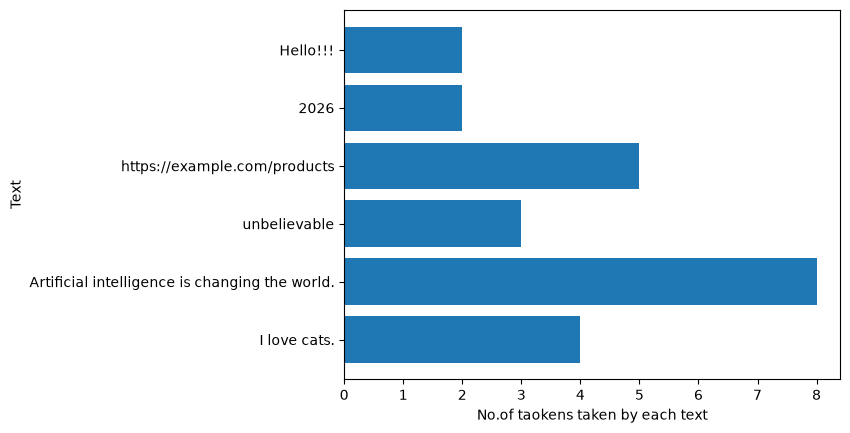

In [36]:
# making vissulization of token usage 
import matplotlib.pyplot as plt

toeksLengths = []

for text in texts:
    toeksLengths.append(len(encoding.encode(text)))

plt.barh(texts, toeksLengths)
plt.ylabel("Text")
plt.xlabel("No.of taokens taken by each text")
plt.show()
    

In [49]:
# lets check with Hugging gace tokenization model which is tokenizers.

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

text = 'A model from hugging face for tokenizing..?!'

tokens = tokenizer.tokenize(text)
token_ids = tokenizer.encode(text)

print("Tokens:")
print(tokens)

print("\n", token_ids)

len(tokens)

Tokens:
['a', 'model', 'from', 'hugging', 'face', 'for', 'token', '##izing', '.', '.', '?', '!']

 [101, 1037, 2944, 2013, 17662, 2227, 2005, 19204, 6026, 1012, 1012, 1029, 999, 102]


12

In [51]:
text = "unbelievabled"

tokens = tokenizer.tokenize(text)

print(tokens)

['unbelievable', '##d']


In [53]:
# another tokenizer from the hugging face is LLaMA which is developed by MetaAI
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B")


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Llama-3.2-1B.
401 Client Error. (Request ID: Root=1-6ab653c1-6a6824fa7e2137401fc143c8;bd9db44f-a10d-4fff-b1a5-057562801d68)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.2-1B/resolve/main/config.json.
Access to model meta-llama/Llama-3.2-1B is restricted. You must have access to it and be authenticated to access it. Please log in.

I love cats.

GPT model token Analys :
[40, 3021, 19987, 13] Length : 4

BERT model token Analys :
['i', 'love', 'cats', '.'] Length : 4
Artificial intelligence is changing the world.

GPT model token Analys :
[9470, 16895, 11478, 374, 10223, 279, 1917, 13] Length : 8

BERT model token Analys :
['artificial', 'intelligence', 'is', 'changing', 'the', 'world', '.'] Length : 7
unbelievable

GPT model token Analys :
[359, 32898, 24694] Length : 3

BERT model token Analys :
['unbelievable'] Length : 1
https://example.com/products

GPT model token Analys :
[2485, 1129, 8858, 916, 34580] Length : 5

BERT model token Analys :
['https', ':', '/', '/', 'example', '.', 'com', '/', 'products'] Length : 9
2026

GPT model token Analys :
[2366, 21] Length : 2

BERT model token Analys :
['202', '##6'] Length : 2
Hello!!!

GPT model token Analys :
[9906, 12340] Length : 2

BERT model token Analys :
['hello', '!', '!', '!'] Length : 4


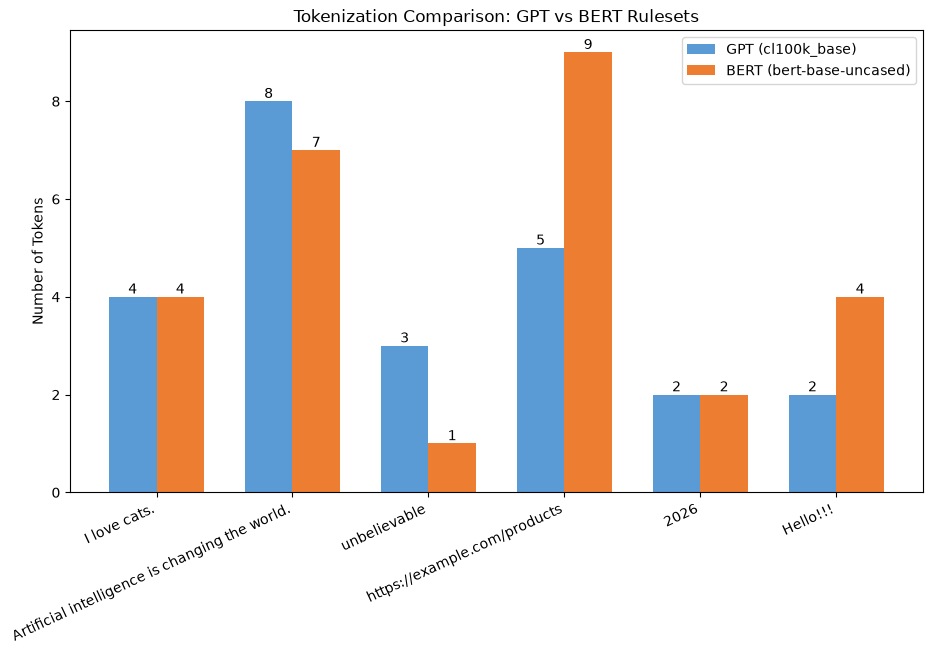

In [69]:
import numpy as np

texts = [
    "I love cats.",
    "Artificial intelligence is changing the world.",
    "unbelievable",
    "https://example.com/products",
    "2026",
    "Hello!!!"
]

# gpt tokenizer which is tiktoken
gpt_encoding = tiktoken.get_encoding("cl100k_base")

gpt_tokens_count = []

# BERT tokenizer
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

bert_tokens_count = []

for text in texts:
    print(text)
    print("\nGPT model token Analys :")
    gpt_token_ids = gpt_encoding.encode(text)
    print(gpt_token_ids, "Length :" ,len(gpt_token_ids))
    
    gpt_tokens_count.append(len(gpt_token_ids))

    print("\nBERT model token Analys :")
    bert_token_ids = bert_tokenizer.tokenize(text)
    print(bert_token_ids, "Length :" ,len(bert_token_ids))
    
    bert_tokens_count.append(len(bert_token_ids))




                             
x_indices = np.arange(len(texts))

plt.figure(figsize=(11, 6))

# Plotting bars side by side using positional offsets
gpt_bars = plt.bar(x_indices - bar_width/2, gpt_tokens_count, bar_width, label='GPT (cl100k_base)', color='#5B9BD5')
bert_bars = plt.bar(x_indices + bar_width/2, bert_tokens_count, bar_width, label='BERT (bert-base-uncased)', color='#ED7D31')

# Value labels on top of each bar 
plt.bar_label(gpt_bars)
plt.bar_label(bert_bars)

# Formatting labels and axes
plt.ylabel('Number of Tokens')
plt.title('Tokenization Comparison: GPT vs BERT Rulesets')
plt.xticks(x_indices, texts, rotation=25, ha='right')
plt.legend()

plt.show()


In [77]:
# we need to check hether the given request is small or large before sending
#for that we maibtian a condition to check whwther th input cross the max_input_token 
#limit that we enetioned at inital stage of te project.

MAX_INPUT_TOKENS = 5000
encoding = tiktoken.get_encoding("cl100k_base")


text = '''# we need to check hether the given request is small or large before sending
#for that we maibtian a condition to check whwther th input cross the max_input_token 
#limit that we enetioned at inital stage of te project.
'''

token_ids = encoding.encode(text)
count  = len(token_ids)

print("Token count:", count)



if count > MAX_INPUT_TOKENS:
    print("Input is too large.")
else:
    print("Input is within the token limit.")

Token count: 53
Input is within the token limit.


In [79]:
# all we done is the token encoding now lets chek the token decoding

print("Text : ",text)

print("\n",token_ids)
print("\n Token Length :" , count)
decoded = encoding.decode(token_ids)

print("\n" , decoded)

Text :  # we need to check hether the given request is small or large before sending
#for that we maibtian a condition to check whwther th input cross the max_input_token 
#limit that we enetioned at inital stage of te project.


 [2, 584, 1205, 311, 1817, 305, 2791, 279, 2728, 1715, 374, 2678, 477, 3544, 1603, 11889, 198, 81517, 430, 584, 7643, 20938, 1122, 264, 3044, 311, 1817, 421, 86, 700, 270, 1988, 5425, 279, 1973, 6022, 6594, 720, 2, 9696, 430, 584, 665, 295, 97657, 520, 304, 2223, 6566, 315, 1028, 2447, 627]

 Token Length : 53

 # we need to check hether the given request is small or large before sending
#for that we maibtian a condition to check whwther th input cross the max_input_token 
#limit that we enetioned at inital stage of te project.

